In [2]:
import os
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils import modeling

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv("../data/creditcard.csv")
# 실제 사용 시 위 코드로 데이터를 로드하세요

In [4]:
import matplotlib

print(matplotlib.rcParams["font.family"])

['Malgun Gothic']


C:\Users\tj\AppData\Local\Temp\ipykernel_14332\2841369093.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_time = df.groupby(time_bins_hourly)["Class"].agg(["sum", "count"])


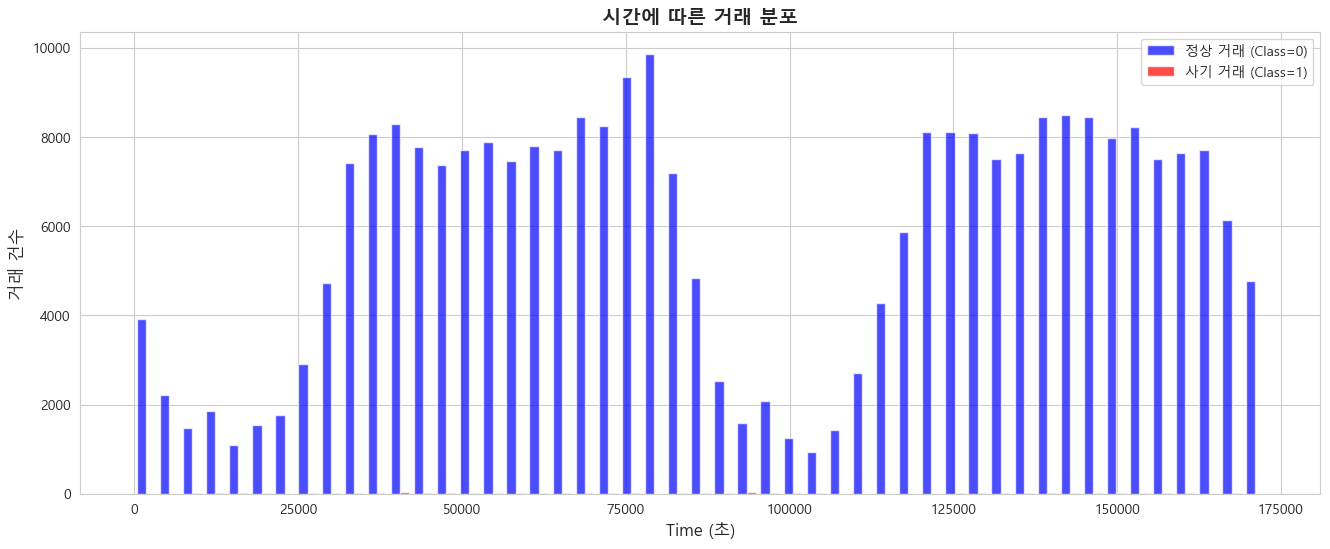

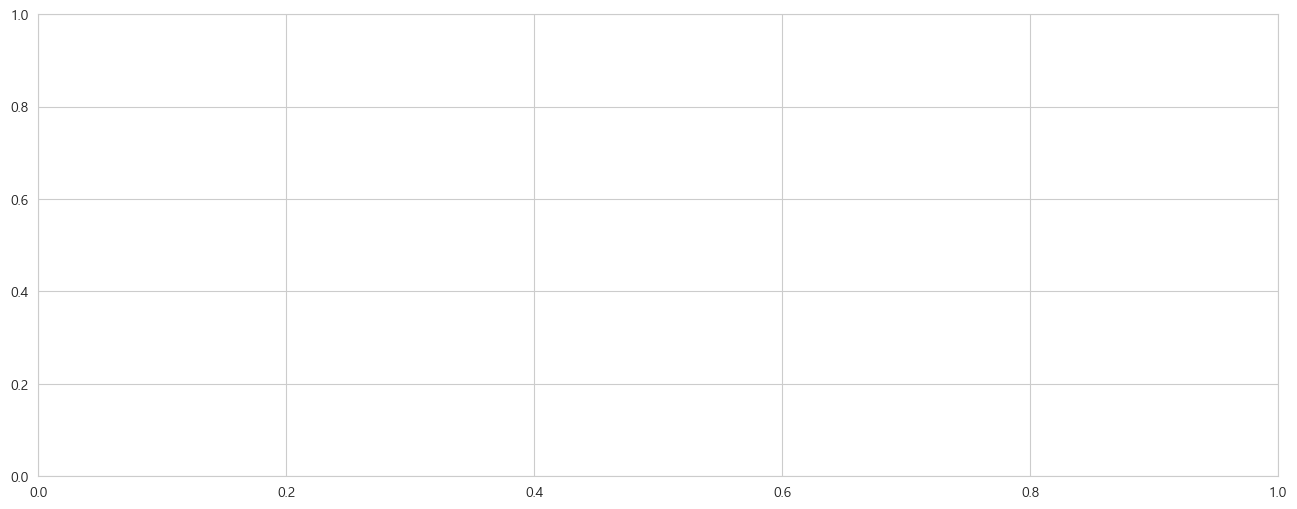

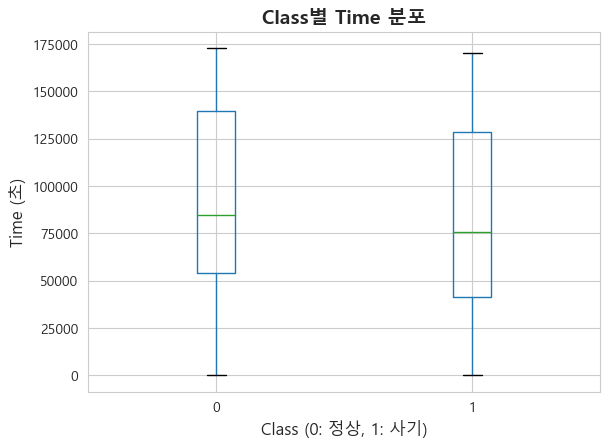

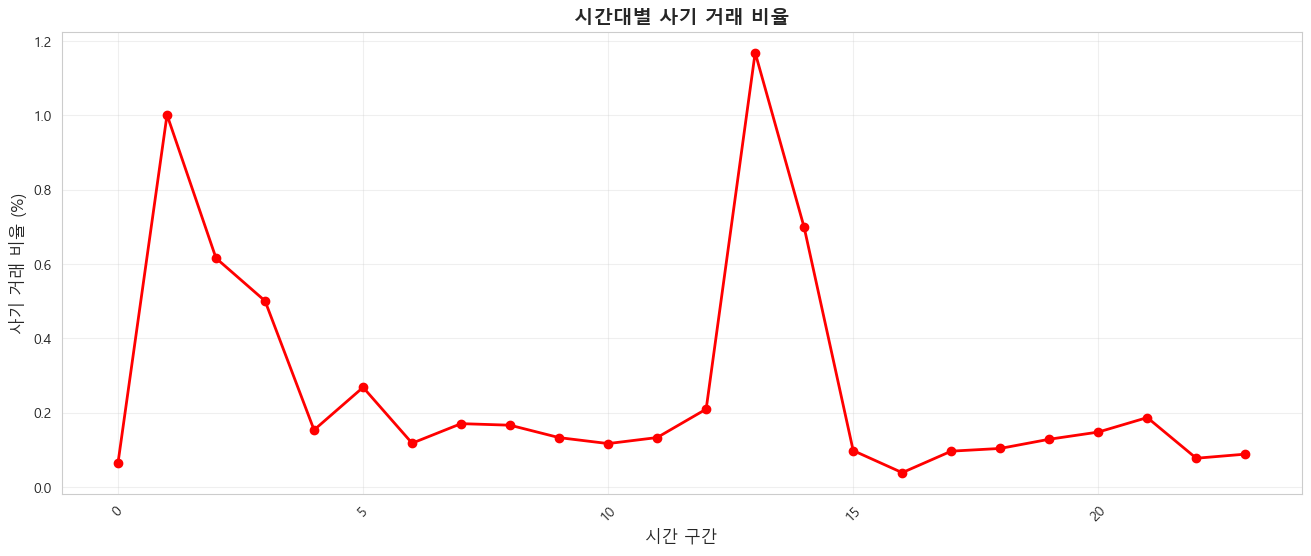

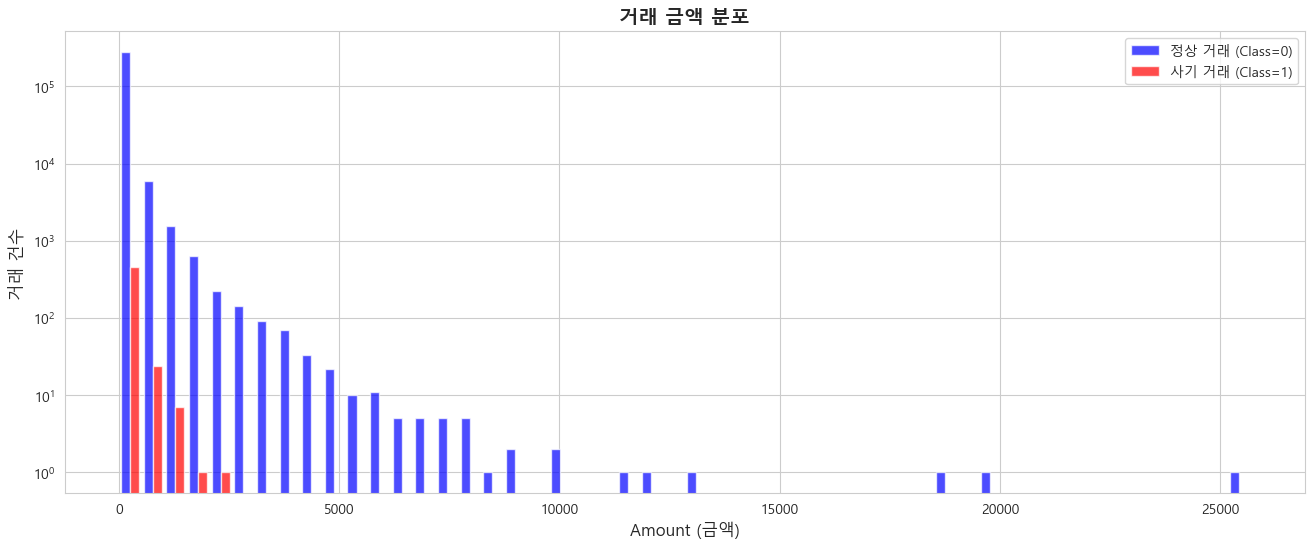

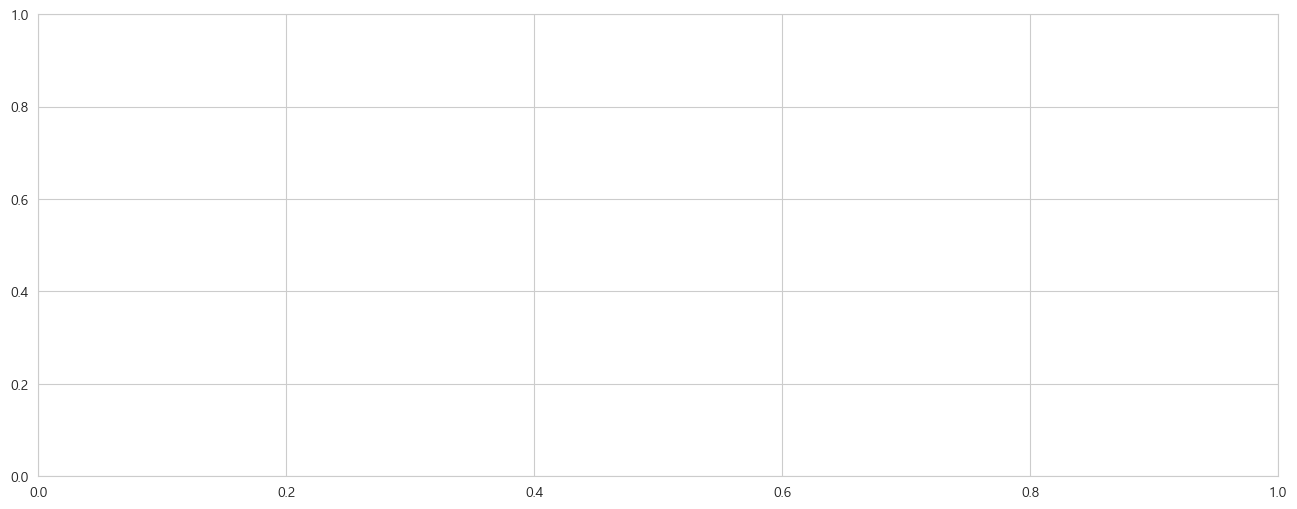

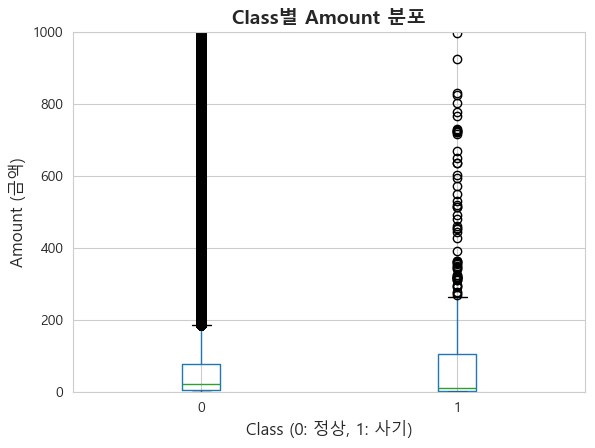

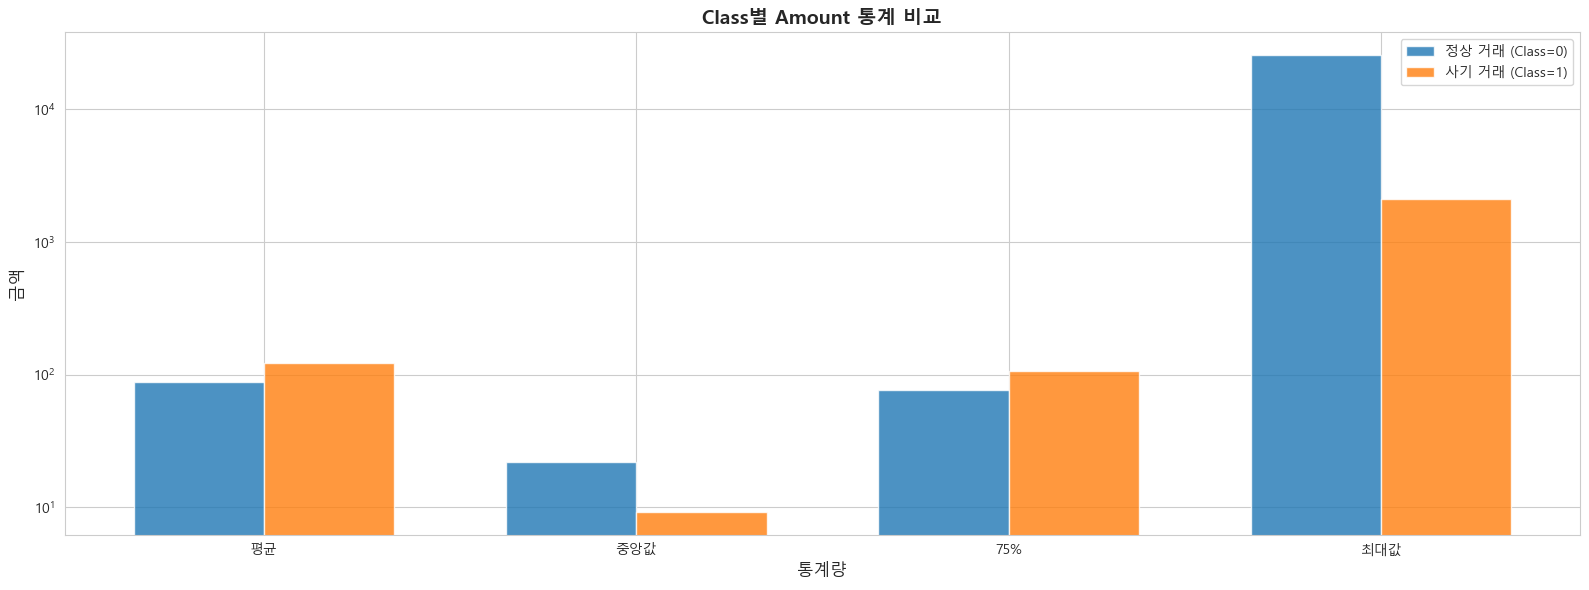

Time 피처 분석

정상 거래 Time 통계:
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64

사기 거래 Time 통계:
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64

Amount 피처 분석

정상 거래 Amount 통계:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

사기 거래 Amount 통계:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

금액대별 사기 거래 비율
0-50: 0.1608% (총 189704건)
50-100: 0.1511% (총 37718건)
100-200

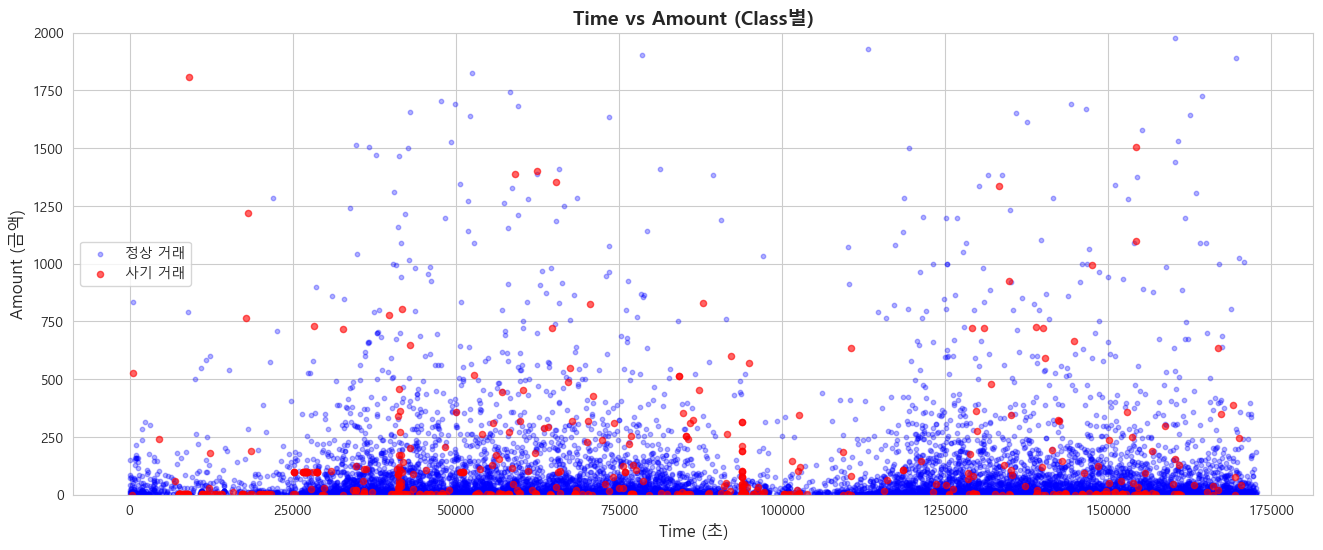

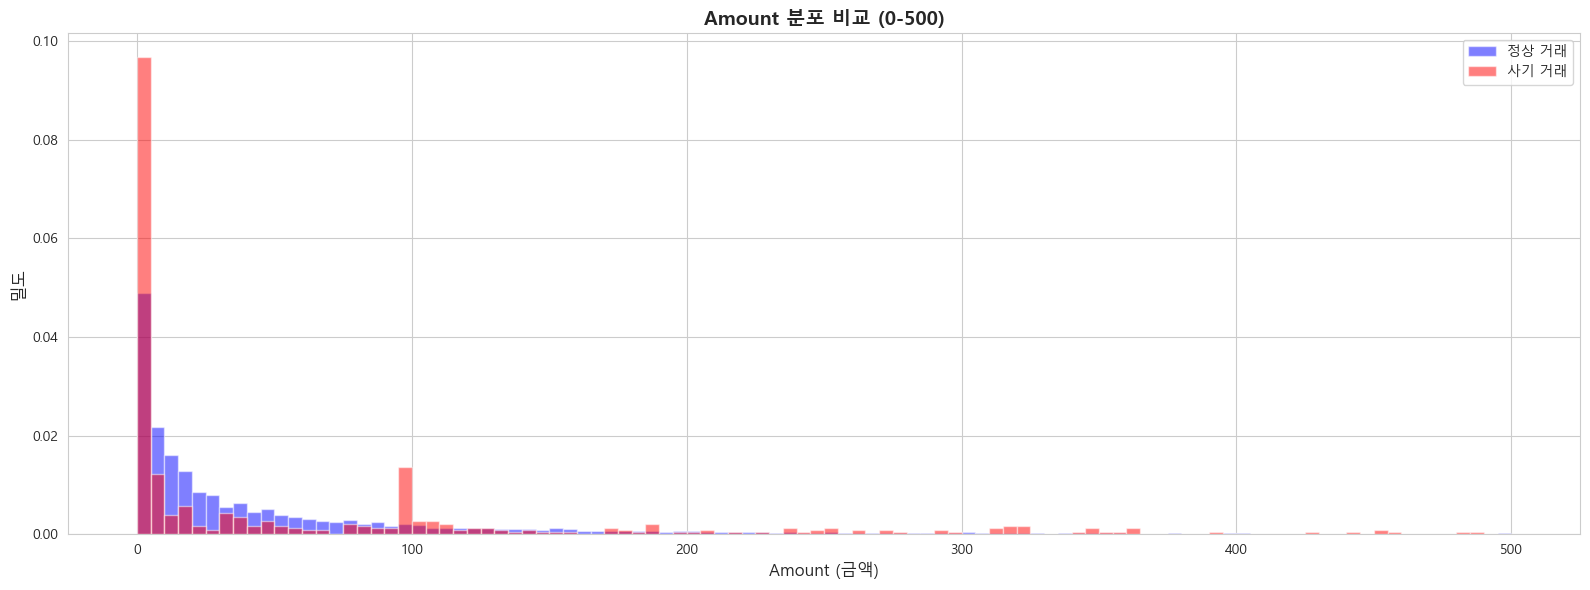

In [5]:
# 시각화 설정
fig4, ax = plt.subplots(figsize=(16, 6))

time_bins = np.linspace(df["Time"].min(), df["Time"].max(), 50)
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

plt.hist(
    [normal["Time"], fraud["Time"]],
    bins=time_bins,
    label=["정상 거래 (Class=0)", "사기 거래 (Class=1)"],
    alpha=0.7,
    color=["blue", "red"],
)
plt.xlabel("Time (초)", fontsize=12)
plt.ylabel("거래 건수", fontsize=12)
plt.title("시간에 따른 거래 분포", fontsize=14, fontweight="bold")
plt.legend()

# 2. Time vs Class - Boxplot
fig5, ax = plt.subplots(figsize=(16, 6))
df.boxplot(column="Time", by="Class")
plt.xlabel("Class (0: 정상, 1: 사기)", fontsize=12)
plt.ylabel("Time (초)", fontsize=12)
plt.title("Class별 Time 분포", fontsize=14, fontweight="bold")
plt.suptitle("")

# 3. Time vs Class - 시간대별 사기 비율
fig5, ax = plt.subplots(figsize=(16, 6))
time_bins_hourly = pd.cut(df["Time"], bins=24)
fraud_rate_by_time = df.groupby(time_bins_hourly)["Class"].agg(["sum", "count"])
fraud_rate_by_time["fraud_rate"] = (
    fraud_rate_by_time["sum"] / fraud_rate_by_time["count"] * 100
)

plt.plot(
    range(len(fraud_rate_by_time)),
    fraud_rate_by_time["fraud_rate"],
    marker="o",
    linewidth=2,
    markersize=6,
    color="red",
)
plt.xlabel("시간 구간", fontsize=12)
plt.ylabel("사기 거래 비율 (%)", fontsize=12)
plt.title("시간대별 사기 거래 비율", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 4. Amount vs Class - 금액 분포 (로그 스케일)
fig5, ax = plt.subplots(figsize=(16, 6))
plt.hist(
    [normal["Amount"], fraud["Amount"]],
    bins=50,
    label=["정상 거래 (Class=0)", "사기 거래 (Class=1)"],
    alpha=0.7,
    color=["blue", "red"],
)
plt.xlabel("Amount (금액)", fontsize=12)
plt.ylabel("거래 건수", fontsize=12)
plt.title("거래 금액 분포", fontsize=14, fontweight="bold")
plt.yscale("log")
plt.legend()

# 5. Amount vs Class - Boxplot
fig6, ax = plt.subplots(figsize=(16, 6))
df.boxplot(column="Amount", by="Class")
plt.xlabel("Class (0: 정상, 1: 사기)", fontsize=12)
plt.ylabel("Amount (금액)", fontsize=12)
plt.title("Class별 Amount 분포", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.ylim(0, 1000)  # 극단값 제외하여 보기 쉽게

# 6. Amount 통계 비교
fig7, ax = plt.subplots(figsize=(16, 6))
amount_stats = df.groupby("Class")["Amount"].describe()[["mean", "50%", "75%", "max"]]
amount_stats = amount_stats.T

x = np.arange(len(amount_stats.index))
width = 0.35

bars1 = plt.bar(
    x - width / 2, amount_stats[0], width, label="정상 거래 (Class=0)", alpha=0.8
)
bars2 = plt.bar(
    x + width / 2, amount_stats[1], width, label="사기 거래 (Class=1)", alpha=0.8
)

plt.xlabel("통계량", fontsize=12)
plt.ylabel("금액", fontsize=12)
plt.title("Class별 Amount 통계 비교", fontsize=14, fontweight="bold")
plt.xticks(x, ["평균", "중앙값", "75%", "최대값"])
plt.legend()
plt.yscale("log")

plt.tight_layout()
# plt.savefig("credit_card_fraud_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# 추가 분석: 상세 통계
print("=" * 60)
print("Time 피처 분석")
print("=" * 60)
print("\n정상 거래 Time 통계:")
print(normal["Time"].describe())
print("\n사기 거래 Time 통계:")
print(fraud["Time"].describe())

print("\n" + "=" * 60)
print("Amount 피처 분석")
print("=" * 60)
print("\n정상 거래 Amount 통계:")
print(normal["Amount"].describe())
print("\n사기 거래 Amount 통계:")
print(fraud["Amount"].describe())

print("\n" + "=" * 60)
print("금액대별 사기 거래 비율")
print("=" * 60)
amount_ranges = [
    (0, 50),
    (50, 100),
    (100, 200),
    (200, 500),
    (500, 1000),
    (1000, float("inf")),
]
for low, high in amount_ranges:
    range_data = df[(df["Amount"] >= low) & (df["Amount"] < high)]
    if len(range_data) > 0:
        fraud_rate = (range_data["Class"].sum() / len(range_data)) * 100
        print(
            f"{low}-{high if high != float('inf') else '+'}: {fraud_rate:.4f}% (총 {len(range_data)}건)"
        )

# Scatter Plot (선택적 - 샘플링하여 시각화)
fig2, ax1 = plt.subplots(figsize=(16, 6))

# 샘플링 (전체 데이터가 너무 많을 경우)
sample_size = min(10000, len(normal))
normal_sample = normal.sample(n=sample_size, random_state=42)
fraud_sample = fraud.sample(n=min(len(fraud), sample_size), random_state=42)

# Time vs Amount scatter
ax1.scatter(
    normal_sample["Time"],
    normal_sample["Amount"],
    alpha=0.3,
    s=10,
    label="정상 거래",
    color="blue",
)
ax1.scatter(
    fraud_sample["Time"],
    fraud_sample["Amount"],
    alpha=0.6,
    s=20,
    label="사기 거래",
    color="red",
)
ax1.set_xlabel("Time (초)", fontsize=12)
ax1.set_ylabel("Amount (금액)", fontsize=12)
ax1.set_title("Time vs Amount (Class별)", fontsize=14, fontweight="bold")
ax1.legend()
ax1.set_ylim(0, 2000)  # 가독성을 위해 y축 제한

fig3, ax = plt.subplots(figsize=(16, 6))
# Amount 분포 비교 (KDE)
ax.hist(
    normal["Amount"],
    bins=100,
    alpha=0.5,
    label="정상 거래",
    color="blue",
    density=True,
    range=(0, 500),
)
ax.hist(
    fraud["Amount"],
    bins=100,
    alpha=0.5,
    label="사기 거래",
    color="red",
    density=True,
    range=(0, 500),
)
ax.set_xlabel("Amount (금액)", fontsize=12)
ax.set_ylabel("밀도", fontsize=12)
ax.set_title("Amount 분포 비교 (0-500)", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
# plt.savefig("credit_card_fraud_scatter.png", dpi=300, bbox_inches="tight")
plt.show()